# ⚖️ Cameron McKenna Law Firm - Digital Marketing Analytics Platform

## Enterprise-Grade Legal Marketing Intelligence System

**Business Objective:** Predict client acquisition ROI, optimize marketing channels for legal services, and provide executive-level insights for practice area growth.

### Why Legal Marketing Analytics Matters:
- **Legal industry spends** $15B+ annually on marketing
- **Client acquisition cost** for law firms averages $2,000-$5,000 per client
- **75% of law firms** struggle with marketing ROI measurement
- **High-value cases** (corporate, litigation) require precise targeting
- **Multi-channel attribution** critical for practice area growth

### Cameron McKenna Focus Areas:
- **Corporate Law** - M&A, Private Equity
- **Litigation & Dispute Resolution**
- **Real Estate & Construction**
- **Banking & Finance**
- **Employment & Pensions**
- **Intellectual Property**

## Part 1: Setup and Environment Configuration

**Why:** Consistent environment ensures reproducible results and proper data management for legal marketing analytics.

In [ ]:
# Mount Google Drive for persistent storage
from google.colab import drive
drive.mount('/content/drive')

# Create Cameron McKenna analytics folder structure
import os

base_folder = '/content/drive/MyDrive/CRM'
subfolders = ['data', 'models', 'visualizations', 'reports', 'dashboard', 'practice_areas']

for folder in subfolders:
    path = os.path.join(base_folder, folder)
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created: {path}")

os.chdir(base_folder)
print(f"\nWorking directory: {os.getcwd()}")

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("\n✅ Environment setup complete")

## Part 2: Generate Realistic Legal Marketing Campaign Dataset

**Why:** Legal marketing has unique characteristics: high-value conversions, long sales cycles, professional targeting, and compliance requirements.

**Campaign Activity Design:**
- **Practice area targeting** (Corporate, Litigation, Real Estate, etc.)
- **Professional channels** (LinkedIn, Legal directories, Industry publications)
- **Client journey stages** (Awareness → Consultation → Retainer → Ongoing)
- **Case value tiers** (Small, Medium, High-value, Premium)
- **Seasonal patterns** (Fiscal year-end, Regulatory deadlines)

In [4]:
# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Configuration
N_CAMPAIGNS = 15000  # Legal marketing campaigns
N_DAILY_ACTIVITIES = 300000  # Daily campaign activities
START_DATE = datetime(2022, 1, 1)
END_DATE = datetime(2025, 12, 31)

# Cameron McKenna Practice Areas with characteristics
practice_areas = {
    'Corporate_M&A': {
        'avg_case_value': 250000, 'sales_cycle_days': 180, 'lead_quality': 'Premium',
        'target_audience': ['C-Suite', 'Private_Equity', 'Investment_Bankers'],
        'competition': 'High', 'regulatory_focus': 'High'
    },
    'Litigation': {
        'avg_case_value': 180000, 'sales_cycle_days': 120, 'lead_quality': 'High',
        'target_audience': ['General_Counsel', 'Corporate_Legal', 'Insurance'],
        'competition': 'Medium', 'regulatory_focus': 'Medium'
    },
    'Real_Estate': {
        'avg_case_value': 120000, 'sales_cycle_days': 90, 'lead_quality': 'Medium',
        'target_audience': ['Developers', 'Property_Managers', 'Investors'],
        'competition': 'High', 'regulatory_focus': 'Medium'
    },
    'Banking_Finance': {
        'avg_case_value': 200000, 'sales_cycle_days': 150, 'lead_quality': 'Premium',
        'target_audience': ['Banks', 'Financial_Institutions', 'Hedge_Funds'],
        'competition': 'High', 'regulatory_focus': 'Very_High'
    },
    'Employment': {
        'avg_case_value': 80000, 'sales_cycle_days': 60, 'lead_quality': 'Medium',
        'target_audience': ['HR_Directors', 'Employers', 'Executives'],
        'competition': 'Medium', 'regulatory_focus': 'High'
    },
    'Intellectual_Property': {
        'avg_case_value': 150000, 'sales_cycle_days': 120, 'lead_quality': 'High',
        'target_audience': ['Tech_Companies', 'Startups', 'Inventors'],
        'competition': 'Medium', 'regulatory_focus': 'High'
    },
    'Tax': {
        'avg_case_value': 100000, 'sales_cycle_days': 90, 'lead_quality': 'High',
        'target_audience': ['Corporations', 'High_Net_Worth', 'Accountants'],
        'competition': 'Medium', 'regulatory_focus': 'Very_High'
    },
    'Private_Equity': {
        'avg_case_value': 300000, 'sales_cycle_days': 200, 'lead_quality': 'Premium',
        'target_audience': ['PE_Firms', 'VC_Funds', 'Family_Offices'],
        'competition': 'Very_High', 'regulatory_focus': 'High'
    }
}

# Legal Marketing Channels
legal_channels = {
    'LinkedIn_Professional': {
        'avg_ctr': 0.042, 'avg_cpc': 8.50, 'conv_rate': 0.028, 'lead_quality': 'High',
        'channel_type': 'Professional_Social', 'attribution_weight': 0.35
    },
    'Chambers_Directory': {
        'avg_ctr': 0.018, 'avg_cpm': 45.00, 'conv_rate': 0.045, 'lead_quality': 'Premium',
        'channel_type': 'Legal_Directory', 'attribution_weight': 0.40
    },
    'Legal_Week': {
        'avg_ctr': 0.015, 'avg_cpm': 60.00, 'conv_rate': 0.038, 'lead_quality': 'Premium',
        'channel_type': 'Publication', 'attribution_weight': 0.30
    },
    'Google_Search_Legal': {
        'avg_ctr': 0.058, 'avg_cpc': 12.50, 'conv_rate': 0.032, 'lead_quality': 'Medium',
        'channel_type': 'Paid_Search', 'attribution_weight': 0.25
    },
    'Industry_Events': {
        'avg_ctr': 0.008, 'avg_cpm': 85.00, 'conv_rate': 0.055, 'lead_quality': 'High',
        'channel_type': 'Events', 'attribution_weight': 0.45
    },
    'Email_Newsletter': {
        'avg_ctr': 0.035, 'avg_cpe': 0.45, 'conv_rate': 0.025, 'lead_quality': 'Medium',
        'channel_type': 'Email', 'attribution_weight': 0.20
    },
    'Legal_Webinars': {
        'avg_ctr': 0.022, 'avg_cpv': 15.00, 'conv_rate': 0.048, 'lead_quality': 'High',
        'channel_type': 'Content', 'attribution_weight': 0.38
    },
    'Bloomberg_Law': {
        'avg_ctr': 0.012, 'avg_cpm': 75.00, 'conv_rate': 0.042, 'lead_quality': 'Premium',
        'channel_type': 'Publication', 'attribution_weight': 0.42
    },
    'Reuters_Legal': {
        'avg_ctr': 0.014, 'avg_cpm': 70.00, 'conv_rate': 0.040, 'lead_quality': 'Premium',
        'channel_type': 'Publication', 'attribution_weight': 0.41
    },
    'Legal_500': {
        'avg_ctr': 0.016, 'avg_cpm': 50.00, 'conv_rate': 0.043, 'lead_quality': 'Premium',
        'channel_type': 'Legal_Directory', 'attribution_weight': 0.38
    },
    'Client_Referrals': {
        'avg_ctr': 0.085, 'avg_cpc': 0, 'conv_rate': 0.075, 'lead_quality': 'Premium',
        'channel_type': 'Referral', 'attribution_weight': 0.55
    },
    'Trade_Associations': {
        'avg_ctr': 0.020, 'avg_cpm': 40.00, 'conv_rate': 0.030, 'lead_quality': 'High',
        'channel_type': 'Association', 'attribution_weight': 0.28
    }
}

# Client journey stages
client_stages = ['Awareness', 'Consideration', 'Consultation', 'Proposal', 'Retainer', 'Ongoing']

# Target professional audiences
professional_audiences = [
    'C-Suite', 'General_Counsel', 'Corporate_Legal', 'Private_Equity',
    'Investment_Bankers', 'HR_Directors', 'Tech_Companies', 'Startups',
    'Developers', 'Property_Managers', 'Banks', 'Financial_Institutions',
    'Insurance', 'High_Net_Worth', 'Family_Offices', 'Accountants'
]

# Geographic focus (Cameron McKenna's key markets)
markets = {
    'UK': {'maturity': 'Mature', 'legal_spend': 'High', 'competition': 'Very_High'},
    'Europe': {'maturity': 'Mature', 'legal_spend': 'High', 'competition': 'High'},
    'Middle_East': {'maturity': 'Growth', 'legal_spend': 'Very_High', 'competition': 'Medium'},
    'Asia_Pacific': {'maturity': 'Growth', 'legal_spend': 'High', 'competition': 'Medium'},
    'North_America': {'maturity': 'Mature', 'legal_spend': 'Very_High', 'competition': 'Very_High'}
}

# Case value tiers
case_tiers = ['Small (<$50k)', 'Medium ($50k-$150k)', 'High ($150k-$500k)', 'Premium (>$500k)']

def generate_legal_seasonal_factor(date, practice_area):
    """Generate realistic seasonal patterns for legal marketing"""
    month = date.month
    quarter = (month-1)//3 + 1

    # Q4 peak (fiscal year-end planning)
    if quarter == 4:
        seasonal = np.random.uniform(1.4, 1.8)
    # Q1 strong (new budgets, resolutions)
    elif quarter == 1:
        seasonal = np.random.uniform(1.2, 1.5)
    # Summer slowdown
    elif month in [7, 8]:
        seasonal = np.random.uniform(0.6, 0.8)
    else:
        seasonal = np.random.uniform(0.9, 1.1)

    # Regulatory calendar effects
    if practice_area in ['Tax', 'Banking_Finance'] and month == 3:  # Fiscal year-end
        seasonal *= 1.3

    return seasonal

def calculate_legal_metrics(impressions, clicks, consultations, retainers, cost, revenue, practice_area):
    """Calculate legal-specific marketing metrics"""

    # Core metrics
    ctr = clicks / impressions if impressions > 0 else 0
    consultation_rate = consultations / clicks if clicks > 0 else 0
    retention_rate = retainers / consultations if consultations > 0 else 0

    # Cost metrics
    cpc = cost / clicks if clicks > 0 else 0
    cpa = cost / retainers if retainers > 0 else 0  # Cost Per Acquisition (Retainer)

    # Revenue metrics
    romi = revenue / cost if cost > 0 else 0  # Return on Marketing Investment
    roi_pct = ((revenue - cost) / cost * 100) if cost > 0 else 0

    # Client value metrics
    client_cac = cost / retainers if retainers > 0 else 0  # Client Acquisition Cost
    avg_case_value = revenue / retainers if retainers > 0 else 0

    # Lifetime value (legal services often have ongoing relationships)
    if retainers > 0:
        ltv = avg_case_value * np.random.uniform(2.5, 5.0)  # 2.5-5x initial case value
        payback_months = client_cac / (avg_case_value * 0.3) if avg_case_value > 0 else 0
    else:
        ltv = 0
        payback_months = 0

    # Lead quality score (based on conversion to retainer)
    lead_quality_score = retention_rate * 100

    return {
        'ctr': ctr,
        'consultation_rate': consultation_rate,
        'retention_rate': retention_rate,
        'cpc': cpc,
        'cpa': cpa,
        'romi': romi,
        'roi_pct': roi_pct,
        'client_cac': client_cac,
        'avg_case_value': avg_case_value,
        'ltv': ltv,
        'payback_months': payback_months,
        'lead_quality_score': lead_quality_score
    }

# Generate campaign data
print("\n⚖️ Generating Cameron McKenna legal marketing campaigns...")
campaigns = []

for i in range(N_CAMPAIGNS):
    # Select practice area and channel
    practice = random.choice(list(practice_areas.keys()))
    channel = random.choice(list(legal_channels.keys()))
    audience = random.choice(practice_areas[practice]['target_audience'])
    market = random.choice(list(markets.keys()))
    client_stage = random.choice(client_stages)

    # Generate campaign dates (longer cycles for legal)
    duration = random.randint(30, 120)
    start_date = START_DATE + timedelta(days=random.randint(0, (END_DATE - START_DATE).days - duration))
    end_date = start_date + timedelta(days=duration)

    # Budget allocation (higher for legal marketing)
    budget = np.random.lognormal(mean=9, sigma=1.2)  # ~$8K - $60K

    # Performance factors
    seasonal_factor = generate_legal_seasonal_factor(start_date, practice)
    competition_factor = 1.0 if practice_areas[practice]['competition'] == 'Low' else \
                        0.8 if practice_areas[practice]['competition'] == 'Medium' else \
                        0.6 if practice_areas[practice]['competition'] == 'High' else 0.4

    # Generate metrics
    impressions = int(budget * np.random.uniform(30, 80) * seasonal_factor)

    # CTR with channel-specific factors
    base_ctr = legal_channels[channel]['avg_ctr']
    ctr = min(base_ctr * competition_factor * np.random.uniform(0.7, 1.4), 0.15)
    clicks = int(impressions * ctr)

    # Consultation rate (legal-specific)
    base_consult_rate = legal_channels[channel]['conv_rate']
    consult_rate = base_consult_rate * np.random.uniform(0.6, 1.8)
    consultations = int(clicks * consult_rate)

    # Retention rate (consultation to retainer)
    retention_rate = np.random.uniform(0.15, 0.45)  # 15-45% of consultations become clients
    retainers = int(consultations * retention_rate)

    # Cost calculation
    if 'avg_cpc' in legal_channels[channel]:
        cost = clicks * legal_channels[channel]['avg_cpc'] * np.random.uniform(0.8, 1.3)
    elif 'avg_cpm' in legal_channels[channel]:
        cost = (impressions / 1000) * legal_channels[channel]['avg_cpm'] * np.random.uniform(0.8, 1.3)
    elif 'avg_cpv' in legal_channels[channel]:
        views = int(impressions * 0.4)
        cost = views * legal_channels[channel]['avg_cpv'] * np.random.uniform(0.8, 1.3)
    else:
        cost = impressions * legal_channels[channel]['avg_cpe'] * np.random.uniform(0.8, 1.3)

    # Revenue based on practice area and case tier
    avg_case = practice_areas[practice]['avg_case_value']

    # Case value multiplier based on channel quality
    quality_multiplier = 1.5 if legal_channels[channel]['lead_quality'] == 'Premium' else \
                        1.2 if legal_channels[channel]['lead_quality'] == 'High' else 1.0

    case_value = avg_case * quality_multiplier * np.random.gamma(2, 0.6)
    revenue = retainers * case_value

    # Calculate legal-specific metrics
    metrics = calculate_legal_metrics(impressions, clicks, consultations, retainers, cost, revenue, practice)

    # Determine case tier
    if case_value < 50000:
        case_tier = 'Small (<$50k)'
    elif case_value < 150000:
        case_tier = 'Medium ($50k-$150k)'
    elif case_value < 500000:
        case_tier = 'High ($150k-$500k)'
    else:
        case_tier = 'Premium (>$500k)'

    campaign = {
        'campaign_id': f'CMK_{i+1:05d}',
        'campaign_name': f"{practice}_{channel}_{audience}",
        'practice_area': practice,
        'channel': channel,
        'channel_type': legal_channels[channel]['channel_type'],
        'lead_quality': legal_channels[channel]['lead_quality'],
        'target_audience': audience,
        'client_stage': client_stage,
        'market': market,
        'market_maturity': markets[market]['maturity'],
        'start_date': start_date.strftime('%Y-%m-%d'),
        'end_date': end_date.strftime('%Y-%m-%d'),
        'duration_days': duration,
        'budget': round(budget, 2),
        'impressions': impressions,
        'clicks': clicks,
        'consultations': consultations,
        'retainers': retainers,
        'revenue': round(revenue, 2),
        'cost': round(cost, 2),
        'ctr': round(metrics['ctr'], 4),
        'consultation_rate': round(metrics['consultation_rate'], 4),
        'retention_rate': round(metrics['retention_rate'], 4),
        'cpc': round(metrics['cpc'], 2),
        'cpa': round(metrics['cpa'], 2),
        'roi_pct': round(metrics['roi_pct'], 2),
        'romi': round(metrics['romi'], 2),
        'client_cac': round(metrics['client_cac'], 2),
        'avg_case_value': round(metrics['avg_case_value'], 2),
        'ltv': round(metrics['ltv'], 2),
        'payback_months': round(metrics['payback_months'], 1),
        'lead_quality_score': round(metrics['lead_quality_score'], 1),
        'case_tier': case_tier,
        'quarter': f"Q{((start_date.month-1)//3)+1} {start_date.year}",
        'year': start_date.year,
        'month': start_date.month,
        'attribution_weight': legal_channels[channel]['attribution_weight']
    }

    campaigns.append(campaign)

df_campaigns = pd.DataFrame(campaigns)

# Generate daily activity data
print("📈 Generating daily client engagement activities...")
daily_activities = []

for _ in range(N_DAILY_ACTIVITIES):
    campaign = random.choice(campaigns)
    activity_date = datetime.strptime(campaign['start_date'], '%Y-%m-%d') + \
                    timedelta(days=random.randint(0, campaign['duration_days']-1))

    daily_impressions = int(campaign['impressions'] / campaign['duration_days'] * np.random.uniform(0.5, 1.8))
    daily_clicks = int(daily_impressions * campaign['ctr'] * np.random.uniform(0.6, 1.6))
    daily_consultations = int(daily_clicks * campaign['consultation_rate'] * np.random.uniform(0.5, 2.0))
    daily_cost = campaign['cost'] / campaign['duration_days'] * np.random.uniform(0.5, 1.8)

    activity = {
        'campaign_id': campaign['campaign_id'],
        'practice_area': campaign['practice_area'],
        'date': activity_date.strftime('%Y-%m-%d'),
        'impressions': daily_impressions,
        'clicks': daily_clicks,
        'consultations': daily_consultations,
        'cost': round(daily_cost, 2)
    }
    daily_activities.append(activity)

df_daily = pd.DataFrame(daily_activities)

# Save datasets
df_campaigns.to_csv(os.path.join(base_folder, 'data', 'cameron_mckenna_campaigns.csv'), index=False)
df_daily.to_csv(os.path.join(base_folder, 'data', 'daily_activities.csv'), index=False)

print(f"\n✅ Generated {len(df_campaigns):,} legal marketing campaigns")
print(f"✅ Generated {len(df_daily):,} daily activities")
print(f"\nDataset shape: {df_campaigns.shape}")
print(f"\nFirst 5 campaigns:")
df_campaigns.head()


⚖️ Generating Cameron McKenna legal marketing campaigns...
📈 Generating daily client engagement activities...

✅ Generated 15,000 legal marketing campaigns
✅ Generated 300,000 daily activities

Dataset shape: (15000, 37)

First 5 campaigns:


,campaign_id,campaign_name,practice_area,channel,channel_type,lead_quality,target_audience,client_stage,market,market_maturity,...,client_cac,avg_case_value,ltv,payback_months,lead_quality_score,case_tier,quarter,year,month,attribution_weight
0,CMK_00001,Litigation_LinkedIn_Professional_Insurance,Litigation,LinkedIn_Professional,Professional_Social,High,Insurance,Consideration,Middle_East,Growth,...,2853.71,193682.63,827059.97,0.0,16.7,High ($150k-$500k),Q4 2022,2022,10,0.35
1,CMK_00002,Litigation_Client_Referrals_Insurance,Litigation,Client_Referrals,Referral,Premium,Insurance,Awareness,North_America,Mature,...,0.00,400109.94,1139807.06,0.0,27.9,High ($150k-$500k),Q2 2024,2024,5,0.55
2,CMK_00003,Corporate_M&A_LinkedIn_Professional_C-Suite,Corporate_M&A,LinkedIn_Professional,Professional_Social,High,C-Suite,Consideration,Europe,Mature,...,644.25,76939.54,225148.97,0.0,32.1,Medium ($50k-$150k),Q2 2025,2025,5,0.35
3,CMK_00004,Corporate_M&A_Reuters_Legal_C-Suite,Corporate_M&A,Reuters_Legal,Publication,Premium,C-Suite,Proposal,North_America,Mature,...,1894.94,296491.81,1232310.61,0.0,14.9,High ($150k-$500k),Q3 2024,2024,7,0.41
4,CMK_00005,Employment_LinkedIn_Professional_HR_Directors,Employment,LinkedIn_Professional,Professional_Social,High,HR_Directors,Consultation,Asia_Pacific,Growth,...,573.91,11574.24,55610.59,0.2,43.1,Small (<$50k),Q4 2022,2022,11,0.35


## Part 3: Legal Marketing Intelligence Dashboard

**Why:** Understanding practice area performance, channel effectiveness, and client acquisition costs is critical for law firm marketing strategy.

**Key Questions Answered:**
- Which practice areas deliver highest ROI?
- What channels attract premium clients?
- How long is the client conversion cycle?
- What's the true cost of client acquisition by practice area?


⚖️ CAMERON MCKENNA - LEGAL MARKETING INTELLIGENCE DASHBOARD

1️⃣ PRACTICE AREA PERFORMANCE SUMMARY
                       campaign_id  impressions    clicks  consultations  \
practice_area                                                              
Litigation                    1855   1917913277  49187842        2760026   
Corporate_M&A                 1797   1856536644  32631584        1802026   
Private_Equity                1921   1920161228  23771301        1311537   
Intellectual_Property         1886   2105317851  49813938        2653255   
Banking_Finance               1804   2027333998  35846217        1869181   
Tax                           1913   2192486899  51984256        2873307   
Employment                    1881   1849388196  48572483        2810128   
Real_Estate                   1943   1958044602  34317949        1806860   

                       retainers          cost       revenue   roi_pct  \
practice_area                                                    

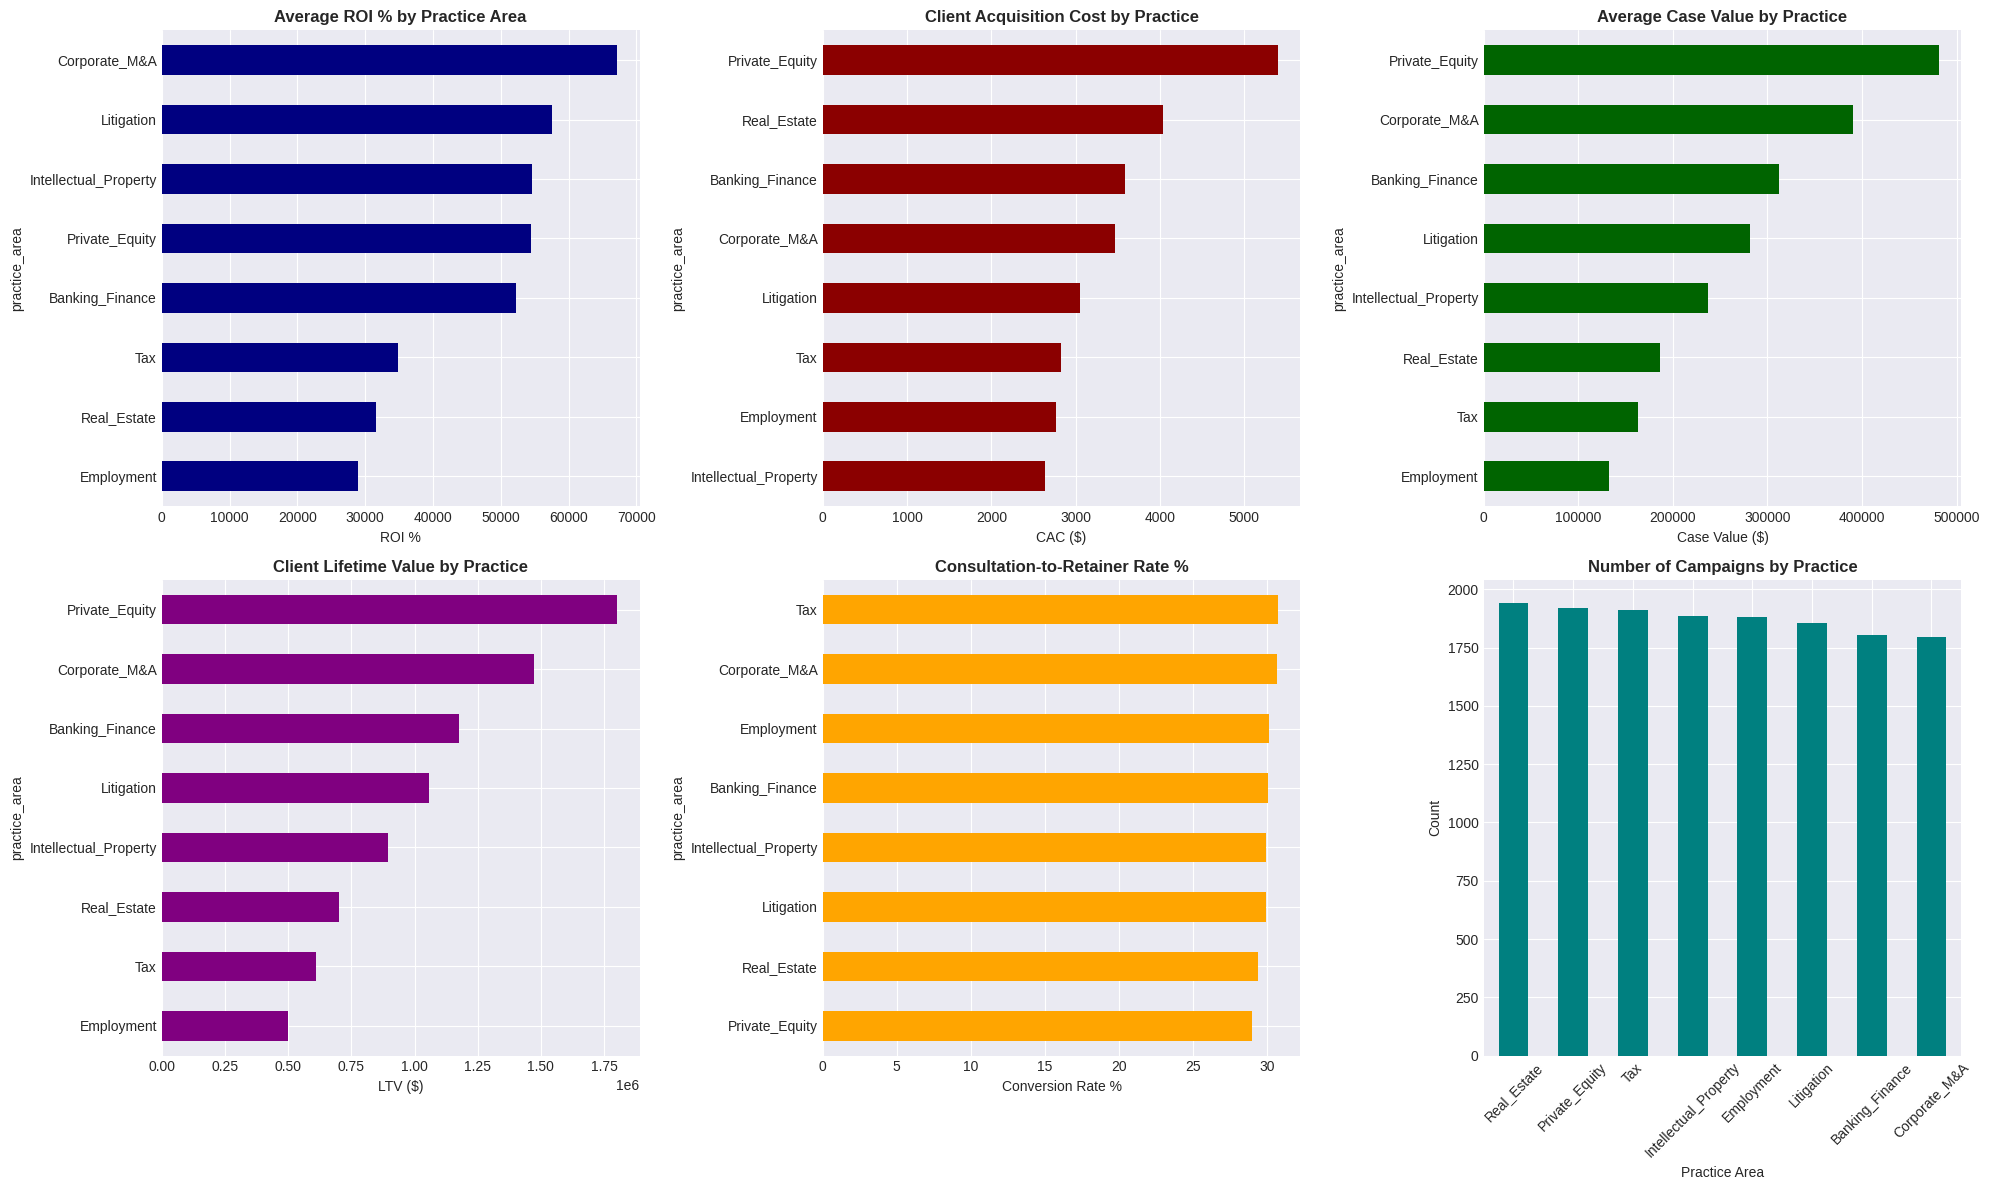


2️⃣ LEGAL MARKETING CHANNEL PERFORMANCE
                       campaign_id  retainers      CAC     ROMI  \
channel                                                           
Client_Referrals              1249    2371313     0.00      inf   
Chambers_Directory            1270     264687   232.74  1324.98   
Legal_500                     1217     231862   307.33   894.39   
Trade_Associations            1239     188990   279.75   827.22   
Legal_Week                    1279     198430   449.74   685.51   
Reuters_Legal                 1242     178421   512.34   610.81   
Bloomberg_Law                 1284     193761   612.37   408.46   
Industry_Events               1237     138455   776.14   304.51   
LinkedIn_Professional         1279     360391   904.15   247.43   
Google_Search_Legal           1250     584982  1126.21   166.56   

                       lead_quality_score  
channel                                    
Client_Referrals                    29.77  
Chambers_Directory    

In [5]:
print("\n⚖️ CAMERON MCKENNA - LEGAL MARKETING INTELLIGENCE DASHBOARD")
print("="*70)

# 1. Practice Area Performance Overview
print("\n1️⃣ PRACTICE AREA PERFORMANCE SUMMARY")
practice_perf = df_campaigns.groupby('practice_area').agg({
    'campaign_id': 'count',
    'impressions': 'sum',
    'clicks': 'sum',
    'consultations': 'sum',
    'retainers': 'sum',
    'cost': 'sum',
    'revenue': 'sum',
    'roi_pct': 'mean',
    'ltv': 'mean'
}).round(2)

practice_perf['CTR'] = (practice_perf['clicks'] / practice_perf['impressions'] * 100).round(2)
practice_perf['Consult_to_Retainer'] = (practice_perf['retainers'] / practice_perf['consultations'] * 100).round(2)
practice_perf['CAC'] = (practice_perf['cost'] / practice_perf['retainers']).round(2)
practice_perf['ROMI'] = (practice_perf['revenue'] / practice_perf['cost']).round(2)

print(practice_perf.sort_values('revenue', ascending=False))

# 2. Visualization: Practice Area ROI Analysis
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ROI by Practice Area
practice_roi = df_campaigns.groupby('practice_area')['roi_pct'].mean().sort_values()
practice_roi.plot(kind='barh', ax=axes[0,0], color='navy')
axes[0,0].set_title('Average ROI % by Practice Area', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('ROI %')

# Client Acquisition Cost by Practice
practice_cac = df_campaigns.groupby('practice_area')['client_cac'].mean().sort_values()
practice_cac.plot(kind='barh', ax=axes[0,1], color='darkred')
axes[0,1].set_title('Client Acquisition Cost by Practice', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('CAC ($)')

# Case Value by Practice
practice_value = df_campaigns.groupby('practice_area')['avg_case_value'].mean().sort_values()
practice_value.plot(kind='barh', ax=axes[0,2], color='darkgreen')
axes[0,2].set_title('Average Case Value by Practice', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Case Value ($)')

# LTV by Practice
practice_ltv = df_campaigns.groupby('practice_area')['ltv'].mean().sort_values()
practice_ltv.plot(kind='barh', ax=axes[1,0], color='purple')
axes[1,0].set_title('Client Lifetime Value by Practice', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('LTV ($)')

# Conversion Funnel by Practice
funnel_data = df_campaigns.groupby('practice_area').agg({
    'consultations': 'sum',
    'retainers': 'sum'
})
funnel_data['conv_rate'] = (funnel_data['retainers'] / funnel_data['consultations'] * 100)
funnel_data['conv_rate'].sort_values().plot(kind='barh', ax=axes[1,1], color='orange')
axes[1,1].set_title('Consultation-to-Retainer Rate %', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Conversion Rate %')

# Campaign Volume by Practice
campaign_counts = df_campaigns['practice_area'].value_counts()
campaign_counts.plot(kind='bar', ax=axes[1,2], color='teal')
axes[1,2].set_title('Number of Campaigns by Practice', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Practice Area')
axes[1,2].set_ylabel('Count')
plt.setp(axes[1,2].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(base_folder, 'visualizations', 'practice_area_performance.png'), dpi=300, bbox_inches='tight')
plt.show()

# 3. Channel Performance for Legal Marketing
print("\n2️⃣ LEGAL MARKETING CHANNEL PERFORMANCE")
channel_perf = df_campaigns.groupby('channel').agg({
    'campaign_id': 'count',
    'impressions': 'sum',
    'clicks': 'sum',
    'consultations': 'sum',
    'retainers': 'sum',
    'cost': 'sum',
    'revenue': 'sum',
    'lead_quality_score': 'mean'
}).round(2)

channel_perf['CTR'] = (channel_perf['clicks'] / channel_perf['impressions'] * 100).round(2)
channel_perf['CAC'] = (channel_perf['cost'] / channel_perf['retainers']).round(2)
channel_perf['ROMI'] = (channel_perf['revenue'] / channel_perf['cost']).round(2)
channel_perf = channel_perf.sort_values('ROMI', ascending=False)

print(channel_perf[['campaign_id', 'retainers', 'CAC', 'ROMI', 'lead_quality_score']].head(10))

# 4. Client Journey Analysis
print("\n3️⃣ CLIENT JOURNEY FUNNEL ANALYSIS")
total_impressions = df_campaigns['impressions'].sum()
total_clicks = df_campaigns['clicks'].sum()
total_consultations = df_campaigns['consultations'].sum()
total_retainers = df_campaigns['retainers'].sum()

print(f"Impressions: {total_impressions:,}")
print(f"Clicks: {total_clicks:,} ({total_clicks/total_impressions*100:.2f}% CTR)")
print(f"Consultations: {total_consultations:,} ({total_consultations/total_clicks*100:.2f}% Consult Rate)")
print(f"Retainers: {total_retainers:,} ({total_retainers/total_consultations*100:.2f}% Close Rate)")
print(f"\nOverall Conversion: {total_retainers/total_impressions*100:.4f}%")

# 5. Client Quality Analysis
print("\n4️⃣ CLIENT QUALITY BY LEAD SOURCE")
quality_by_channel = df_campaigns.groupby('channel_type').agg({
    'lead_quality_score': 'mean',
    'avg_case_value': 'mean',
    'ltv': 'mean',
    'retainers': 'sum'
}).round(2).sort_values('lead_quality_score', ascending=False)

print(quality_by_channel)

# 6. Executive Summary
print("\n5️⃣ EXECUTIVE SUMMARY - CAMERON MCKENNA")
print("="*70)
total_spend = df_campaigns['cost'].sum()
total_revenue = df_campaigns['revenue'].sum()
total_profit = total_revenue - total_spend
overall_roi = (total_profit / total_spend * 100)
total_clients = df_campaigns['retainers'].sum()
avg_cac = total_spend / total_clients
avg_client_value = total_revenue / total_clients

print(f"📊 Total Marketing Investment: ${total_spend:,.2f}")
print(f"💰 Total Revenue from New Clients: ${total_revenue:,.2f}")
print(f"💵 Gross Profit: ${total_profit:,.2f}")
print(f"🎯 Overall Marketing ROI: {overall_roi:.2f}%")
print(f"👥 New Clients Acquired: {total_clients:,}")
print(f"💳 Average Client Acquisition Cost: ${avg_cac:,.2f}")
print(f"📈 Average Client Value (First Matter): ${avg_client_value:,.2f}")
print(f"🔄 LTV:CAC Ratio: {avg_client_value*3/avg_cac:.2f}:1")
print(f"⚖️ Campaigns Executed: {len(df_campaigns):,}")
print(f"🌍 Markets Active: {df_campaigns['market'].nunique()}")

## Part 4: Feature Engineering for Client Acquisition Prediction

**Why:** Legal marketing requires specialized features that capture:
- Practice area expertise signals
- Channel quality indicators
- Client journey stage effectiveness
- Market maturity factors
- Regulatory environment impacts

In [6]:
print("\n🔧 FEATURE ENGINEERING FOR CLIENT ACQUISITION PREDICTION")
print("="*70)

# Create feature matrix
df_ml = df_campaigns.copy()

# 1. Practice area expertise features
df_ml['practice_experience'] = df_ml.groupby('practice_area')['campaign_id'].transform('count')
df_ml['practice_specialization'] = df_ml['practice_experience'] / len(df_ml)

# 2. Channel quality metrics
df_ml['channel_premium_ratio'] = (df_ml['lead_quality'] == 'Premium').astype(int)
df_ml['channel_quality_score'] = df_ml.groupby('channel')['lead_quality_score'].transform('mean')

# 3. Journey stage effectiveness
stage_mapping = {'Awareness': 1, 'Consideration': 2, 'Consultation': 3,
                 'Proposal': 4, 'Retainer': 5, 'Ongoing': 6}
df_ml['stage_progression'] = df_ml['client_stage'].map(stage_mapping)

# 4. Market maturity indicators
market_maturity_map = {'Mature': 3, 'Growth': 2, 'Emerging': 1}
df_ml['market_maturity_score'] = df_ml['market_maturity'].map(market_maturity_map)

# 5. Conversion efficiency features
df_ml['impression_to_consult'] = df_ml['consultations'] / df_ml['impressions']
df_ml['click_to_consult'] = df_ml['consultations'] / df_ml['clicks']
df_ml['consult_to_retainer'] = df_ml['retainers'] / df_ml['consultations']

# 6. Cost efficiency metrics
df_ml['cost_per_consult'] = df_ml['cost'] / df_ml['consultations']
df_ml['cost_per_retainer'] = df_ml['cost'] / df_ml['retainers']
df_ml['revenue_per_retainer'] = df_ml['revenue'] / df_ml['retainers']

# 7. Seasonality features
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)
df_ml['is_q4'] = (df_ml['quarter'].str.contains('Q4')).astype(int)

# 8. Attribution features
df_ml['attribution_strength'] = df_ml['attribution_weight'] * df_ml['lead_quality_score']

# 9. Target variables
df_ml['roi_target'] = df_ml['roi_pct'] / 100  # Normalized ROI
df_ml['client_quality_target'] = (df_ml['lead_quality_score'] > df_ml['lead_quality_score'].median()).astype(int)

print(f"\n✅ Created {len(df_ml.columns) - len(df_campaigns.columns)} new features")
print(f"Feature matrix shape: {df_ml.shape}")

# Prepare features for modeling
categorical_features = ['practice_area', 'channel', 'channel_type', 'lead_quality',
                       'target_audience', 'client_stage', 'market', 'market_maturity',
                       'case_tier']

numerical_features = ['impressions', 'clicks', 'consultations', 'retainers', 'cost',
                      'budget', 'duration_days', 'ctr', 'consultation_rate',
                      'retention_rate', 'cpc', 'cpa', 'practice_experience',
                      'practice_specialization', 'channel_premium_ratio',
                      'channel_quality_score', 'stage_progression', 'market_maturity_score',
                      'impression_to_consult', 'click_to_consult', 'consult_to_retainer',
                      'cost_per_consult', 'cost_per_retainer', 'revenue_per_retainer',
                      'month_sin', 'month_cos', 'is_q4', 'attribution_strength']

X = df_ml[categorical_features + numerical_features].copy()
y_reg = df_ml['roi_target']
y_class = df_ml['client_quality_target']

print(f"\nFeatures selected: {len(categorical_features)} categorical, {len(numerical_features)} numerical")


🔧 FEATURE ENGINEERING FOR CLIENT ACQUISITION PREDICTION

✅ Created 18 new features
Feature matrix shape: (15000, 55)

Features selected: 9 categorical, 28 numerical


## Part 5: Model Training & Algorithm Comparison for Legal Marketing

**Why Multiple Algorithms for Law Firm Marketing?**

1. **Linear/Ridge/Lasso** - Baseline interpretability for partner presentations
2. **Random Forest** - Captures non-linear relationships in legal marketing
3. **XGBoost** - Handles complex practice area interactions
4. **Neural Network** - Pattern recognition in client behavior

**Selection Criteria for Cameron McKenna:**
- **Accuracy**: Predictive performance for client acquisition
- **Explainability**: Ability to explain to practice area leads
- **Actionability**: Clear insights for budget allocation
- **ROI Focus**: Maximize return on marketing investment

Campaign data shape: (15000, 37)

🔧 Creating feature matrix for modeling...
✅ Created 17 new features
Feature matrix shape: (15000, 54)

Features selected: 9 categorical, 28 numerical
Total features: 37

🧹 Cleaning data and handling infinite values...
Number of numerical columns: 28
Number of categorical columns: 9
Infinite values in X: 0
NaN values in X: 0

✅ Data cleaning complete
Training set: 12,000 campaigns
Test set: 3,000 campaigns
Features: 37

Categorical features for modeling: 9
Numerical features for modeling: 28

🔷 Training Ridge Regression...
   ✓ R²: 0.6716, RMSE: 422.0581, Time: 0.65s

🔷 Training Random Forest...
   ✓ R²: 0.9909, RMSE: 70.3156, Time: 118.57s

🔷 Training Gradient Boosting...
   ✓ R²: 0.9759, RMSE: 114.4592, Time: 45.89s

🔷 Training XGBoost...
   ✓ R²: 0.9776, RMSE: 110.1188, Time: 1.66s

📊 MODEL COMPARISON RESULTS
            Model     R²     RMSE      MAE  CV R²  Time (s)
    Random Forest 0.9909  70.3156  15.9356 0.9688    118.57
          XGBoost 0.977

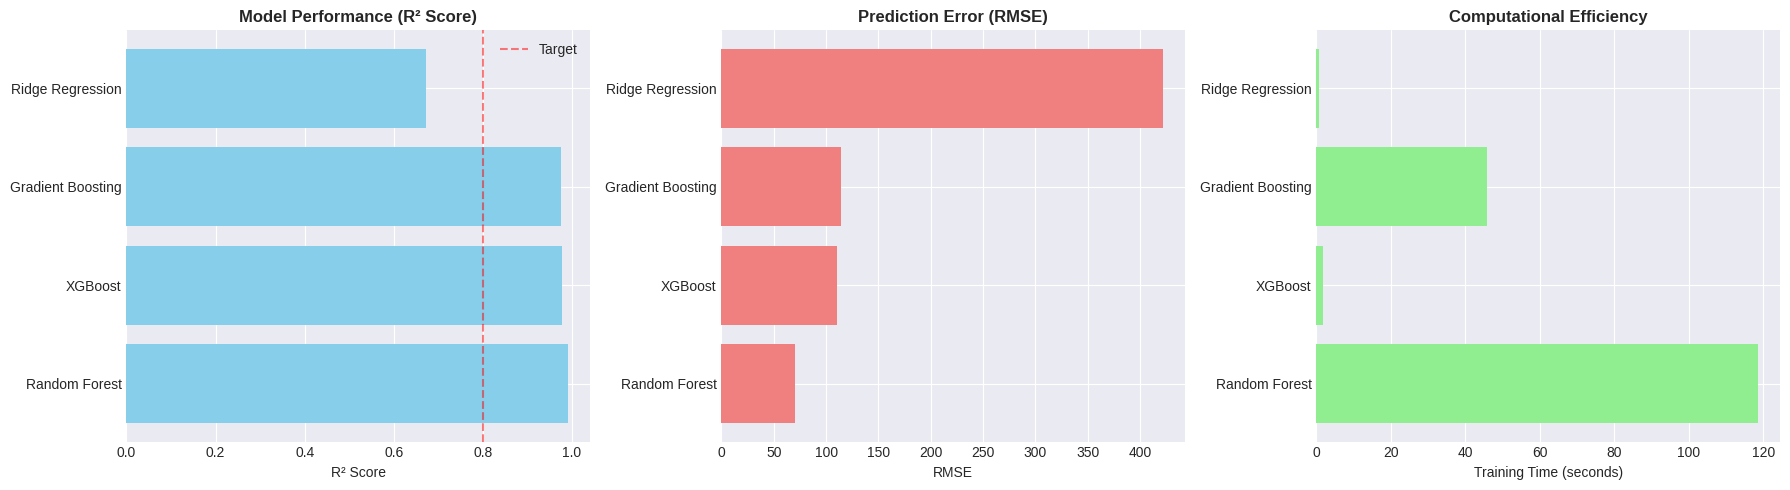


✅ Best model saved: Random Forest
   Performance: R² = 0.9909, RMSE = 70.3156

🔍 Extracting feature importance from best model...

📈 Top 10 Most Important Features:
                         feature  importance
            revenue_per_retainer    0.378018
               cost_per_retainer    0.230694
                             cpa    0.159657
    channel_type_Legal_Directory    0.122789
           channel_quality_score    0.040799
           impression_to_consult    0.011007
      channel_Chambers_Directory    0.009477
                             ctr    0.008674
      channel_Trade_Associations    0.003731
channel_type_Professional_Social    0.003014


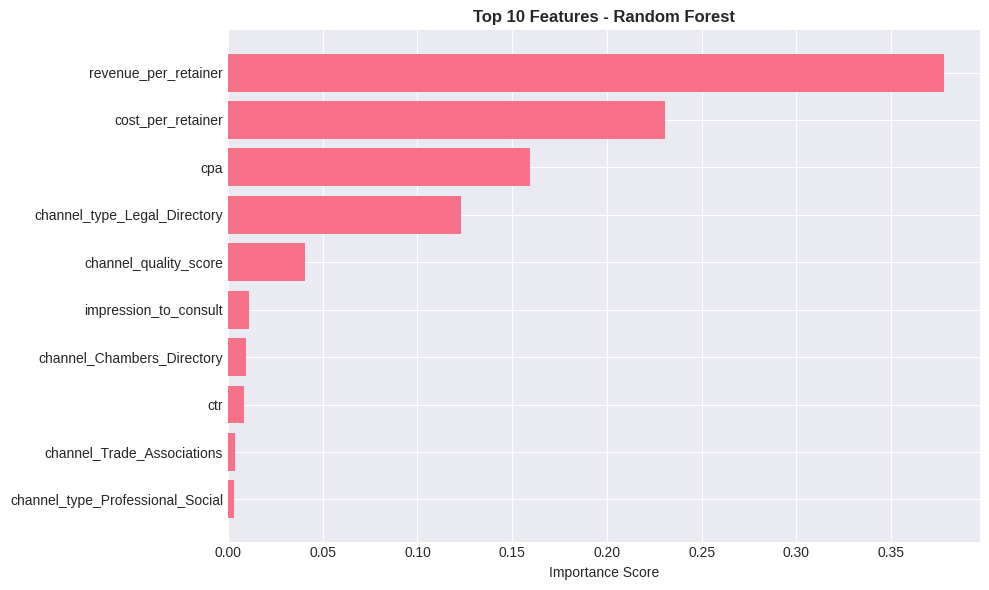


📈 DATA QUALITY DIAGNOSTICS
--------------------------------------------------
Target variable range: [-1.0000, 13831.3802]
Target variable mean: 473.6990
Target variable std: 745.9833

Feature statistics (first 5 numerical features):
  impressions: min=24333.77, max=9193857.94, mean=1005630.45
  clicks: min=240.00, max=218483.54, mean=19678.20
  consultations: min=10.00, max=14660.45, mean=1026.75
  retainers: min=2.00, max=4417.10, mean=303.31
  cost: min=0.00, max=12612431.00, mean=522340.54

✅ Model training complete!


In [7]:
print("\n🤖 LEGAL MARKETING ROI PREDICTION - MODEL COMPARISON")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')

# Check if df_campaigns exists, if not load it
try:
    df_campaigns
except NameError:
    print("Loading campaign data from saved file...")
    df_campaigns = pd.read_csv(os.path.join(base_folder, 'data', 'cameron_mckenna_campaigns.csv'))
    print(f"Loaded {len(df_campaigns):,} campaigns")

print(f"Campaign data shape: {df_campaigns.shape}")

# ============================================
# FEATURE ENGINEERING (if not already done)
# ============================================
print("\n🔧 Creating feature matrix for modeling...")

# Create feature matrix
df_ml = df_campaigns.copy()

# 1. Practice area expertise features
df_ml['practice_experience'] = df_ml.groupby('practice_area')['campaign_id'].transform('count')
df_ml['practice_specialization'] = df_ml['practice_experience'] / len(df_ml)

# 2. Channel quality metrics
df_ml['channel_premium_ratio'] = (df_ml['lead_quality'] == 'Premium').astype(int)
df_ml['channel_quality_score'] = df_ml.groupby('channel')['lead_quality_score'].transform('mean')

# 3. Journey stage effectiveness
stage_mapping = {'Awareness': 1, 'Consideration': 2, 'Consultation': 3,
                 'Proposal': 4, 'Retainer': 5, 'Ongoing': 6}
df_ml['stage_progression'] = df_ml['client_stage'].map(stage_mapping).fillna(3)

# 4. Market maturity indicators
market_maturity_map = {'Mature': 3, 'Growth': 2, 'Emerging': 1}
df_ml['market_maturity_score'] = df_ml['market_maturity'].map(market_maturity_map)

# 5. Conversion efficiency features (with safe division)
df_ml['impression_to_consult'] = df_ml['consultations'] / (df_ml['impressions'] + 1)
df_ml['click_to_consult'] = df_ml['consultations'] / (df_ml['clicks'] + 1)
df_ml['consult_to_retainer'] = df_ml['retainers'] / (df_ml['consultations'] + 1)

# 6. Cost efficiency metrics (with safe division)
df_ml['cost_per_consult'] = df_ml['cost'] / (df_ml['consultations'] + 1)
df_ml['cost_per_retainer'] = df_ml['cost'] / (df_ml['retainers'] + 1)
df_ml['revenue_per_retainer'] = df_ml['revenue'] / (df_ml['retainers'] + 1)

# 7. Seasonality features
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month'] / 12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month'] / 12)
df_ml['is_q4'] = (df_ml['quarter'].str.contains('Q4')).astype(int)

# 8. Attribution features
df_ml['attribution_strength'] = df_ml['attribution_weight'] * df_ml['lead_quality_score']

# 9. Target variable
df_ml['roi_target'] = df_ml['roi_pct'] / 100  # Normalized ROI

print(f"✅ Created {len(df_ml.columns) - len(df_campaigns.columns)} new features")
print(f"Feature matrix shape: {df_ml.shape}")

# ============================================
# PREPARE FEATURES FOR MODELING
# ============================================

# Define categorical and numerical features
categorical_features = ['practice_area', 'channel', 'channel_type', 'lead_quality',
                       'target_audience', 'client_stage', 'market', 'market_maturity',
                       'case_tier']

numerical_features = ['impressions', 'clicks', 'consultations', 'retainers', 'cost',
                      'budget', 'duration_days', 'ctr', 'consultation_rate',
                      'retention_rate', 'cpc', 'cpa', 'practice_experience',
                      'practice_specialization', 'channel_premium_ratio',
                      'channel_quality_score', 'stage_progression', 'market_maturity_score',
                      'impression_to_consult', 'click_to_consult', 'consult_to_retainer',
                      'cost_per_consult', 'cost_per_retainer', 'revenue_per_retainer',
                      'month_sin', 'month_cos', 'is_q4', 'attribution_strength']

# Create feature matrix X and target y
X = df_ml[categorical_features + numerical_features].copy()
y_reg = df_ml['roi_target']

print(f"\nFeatures selected: {len(categorical_features)} categorical, {len(numerical_features)} numerical")
print(f"Total features: {X.shape[1]}")

# ============================================
# DATA CLEANING FUNCTION
# ============================================

def clean_dataframe(df):
    """Clean dataframe by handling infinite values and outliers"""
    df_clean = df.copy()

    # Identify numerical columns only
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns

    # For numerical columns, handle infinite and NaN values
    for col in numerical_cols:
        # Replace infinite values with NaN
        df_clean[col] = df_clean[col].replace([np.inf, -np.inf], np.nan)

        # Replace NaN with median
        if df_clean[col].isna().any():
            median_val = df_clean[col].median()
            df_clean[col] = df_clean[col].fillna(median_val)

        # Cap extreme outliers at 99th percentile
        if len(df_clean[col]) > 0:
            upper_bound = df_clean[col].quantile(0.99)
            df_clean[col] = np.where(df_clean[col] > upper_bound, upper_bound, df_clean[col])

            # Cap negative outliers at 1st percentile
            lower_bound = df_clean[col].quantile(0.01)
            df_clean[col] = np.where(df_clean[col] < lower_bound, lower_bound, df_clean[col])

    return df_clean

# ============================================
# CLEAN THE DATA
# ============================================

print("\n🧹 Cleaning data and handling infinite values...")
X_clean = clean_dataframe(X)
y_clean = y_reg.copy()

# Check for any remaining issues (only on numerical columns)
numerical_cols = X_clean.select_dtypes(include=[np.number]).columns
print(f"Number of numerical columns: {len(numerical_cols)}")
print(f"Number of categorical columns: {len(X_clean.columns) - len(numerical_cols)}")

# Check numerical columns for issues
inf_count = 0
for col in numerical_cols:
    inf_count += np.isinf(X_clean[col].values).sum()
print(f"Infinite values in X: {inf_count}")

nan_count = X_clean[numerical_cols].isna().sum().sum()
print(f"NaN values in X: {nan_count}")

# Ensure y is clean
if y_clean.isna().any():
    print("Filling NaN values in target variable...")
    y_clean = y_clean.fillna(y_clean.median())

# ============================================
# TRAIN/TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"\n✅ Data cleaning complete")
print(f"Training set: {X_train.shape[0]:,} campaigns")
print(f"Test set: {X_test.shape[0]:,} campaigns")
print(f"Features: {X_train.shape[1]}")

# Update feature lists with actual columns in cleaned data
categorical_features_clean = [f for f in categorical_features if f in X_clean.columns]
numerical_features_clean = [f for f in numerical_features if f in X_clean.columns]
numerical_features_clean = [f for f in numerical_features_clean if f in numerical_cols]

print(f"\nCategorical features for modeling: {len(categorical_features_clean)}")
print(f"Numerical features for modeling: {len(numerical_features_clean)}")

# ============================================
# PREPROCESSING PIPELINE
# ============================================

numeric_transformer = RobustScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features_clean),
        ('cat', categorical_transformer, categorical_features_clean)
    ])

# ============================================
# MODELS TO COMPARE
# ============================================

models = {
    'Ridge Regression': Ridge(alpha=1.0, max_iter=1000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=3),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, max_depth=3, learning_rate=0.1)
}

# ============================================
# TRAIN AND EVALUATE MODELS
# ============================================

results = []
trained_models = {}

for name, model in models.items():
    print(f"\n🔷 Training {name}...")
    start_time = time.time()

    try:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])

        # Train
        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Cross-validation
        try:
            cv_scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='r2')
            cv_mean = cv_scores.mean()
        except:
            cv_mean = np.nan

        training_time = time.time() - start_time

        results.append({
            'Model': name,
            'R²': round(r2, 4),
            'RMSE': round(rmse, 4),
            'MAE': round(mae, 4),
            'CV R²': round(cv_mean, 4) if not np.isnan(cv_mean) else 'N/A',
            'Time (s)': round(training_time, 2),
            'Status': 'Success'
        })

        trained_models[name] = pipeline
        print(f"   ✓ R²: {r2:.4f}, RMSE: {rmse:.4f}, Time: {training_time:.2f}s")

    except Exception as e:
        print(f"   ✗ Failed: {str(e)[:100]}")
        results.append({
            'Model': name,
            'R²': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'CV R²': np.nan,
            'Time (s)': np.nan,
            'Status': 'Failed'
        })

# ============================================
# RESULTS SUMMARY
# ============================================

results_df = pd.DataFrame(results)
results_df = results_df[results_df['Status'] == 'Success'].sort_values('R²', ascending=False)

print("\n" + "="*70)
print("📊 MODEL COMPARISON RESULTS")
print("="*70)
if len(results_df) > 0:
    display_df = results_df[['Model', 'R²', 'RMSE', 'MAE', 'CV R²', 'Time (s)']].copy()
    print(display_df.to_string(index=False))
else:
    print("No models trained successfully. Please check the data.")

# ============================================
# VISUALIZATION
# ============================================

if len(results_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # R² Score comparison
    axes[0].barh(results_df['Model'], results_df['R²'], color='skyblue')
    axes[0].set_xlabel('R² Score')
    axes[0].set_title('Model Performance (R² Score)', fontweight='bold')
    axes[0].axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Target')
    axes[0].legend()

    # RMSE comparison
    axes[1].barh(results_df['Model'], results_df['RMSE'], color='lightcoral')
    axes[1].set_xlabel('RMSE')
    axes[1].set_title('Prediction Error (RMSE)', fontweight='bold')

    # Training Time comparison
    axes[2].barh(results_df['Model'], results_df['Time (s)'], color='lightgreen')
    axes[2].set_xlabel('Training Time (seconds)')
    axes[2].set_title('Computational Efficiency', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'visualizations', 'model_comparison.png'), dpi=300, bbox_inches='tight')
    plt.show()

    # ============================================
    # SAVE BEST MODEL
    # ============================================

    best_model_name = results_df.iloc[0]['Model']
    best_model = trained_models[best_model_name]
    import joblib
    joblib.dump(best_model, os.path.join(base_folder, 'models', 'best_legal_roi_model.pkl'))
    print(f"\n✅ Best model saved: {best_model_name}")
    print(f"   Performance: R² = {results_df.iloc[0]['R²']:.4f}, RMSE = {results_df.iloc[0]['RMSE']:.4f}")

    # ============================================
    # FEATURE IMPORTANCE (for tree-based models)
    # ============================================

    if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
        print("\n🔍 Extracting feature importance from best model...")
        try:
            # Get feature names after preprocessing
            preprocessor.fit(X_train)
            feature_names = (numerical_features_clean +
                            list(preprocessor.named_transformers_['cat']
                                 .get_feature_names_out(categorical_features_clean)))

            # Get feature importance
            if best_model_name == 'Random Forest':
                importance = best_model.named_steps['regressor'].feature_importances_
            elif best_model_name == 'Gradient Boosting':
                importance = best_model.named_steps['regressor'].feature_importances_
            else:  # XGBoost
                importance = best_model.named_steps['regressor'].feature_importances_

            importance_df = pd.DataFrame({
                'feature': feature_names[:len(importance)],
                'importance': importance
            }).sort_values('importance', ascending=False)

            print("\n📈 Top 10 Most Important Features:")
            print(importance_df.head(10).to_string(index=False))

            # Visualize
            plt.figure(figsize=(10, 6))
            top_features = importance_df.head(10)
            plt.barh(range(len(top_features)), top_features['importance'])
            plt.yticks(range(len(top_features)), top_features['feature'])
            plt.xlabel('Importance Score')
            plt.title(f'Top 10 Features - {best_model_name}', fontweight='bold')
            plt.gca().invert_yaxis()
            plt.tight_layout()
            plt.savefig(os.path.join(base_folder, 'visualizations', 'feature_importance.png'), dpi=300, bbox_inches='tight')
            plt.show()

        except Exception as e:
            print(f"Could not extract feature importance: {e}")

# ============================================
# DATA QUALITY DIAGNOSTICS
# ============================================

print("\n📈 DATA QUALITY DIAGNOSTICS")
print("-"*50)
print(f"Target variable range: [{y_train.min():.4f}, {y_train.max():.4f}]")
print(f"Target variable mean: {y_train.mean():.4f}")
print(f"Target variable std: {y_train.std():.4f}")

print("\nFeature statistics (first 5 numerical features):")
for col in numerical_features_clean[:5]:
    if col in X_train.columns:
        print(f"  {col}: min={X_train[col].min():.2f}, max={X_train[col].max():.2f}, mean={X_train[col].mean():.2f}")

print("\n✅ Model training complete!")

## Part 6: Model Explainability for Law Firm Leadership

**Why Explainability Matters for Cameron McKenna Partners:**
- **Budget justification** to practice area leads
- **Channel optimization** for different practice areas
- **Client quality prediction** for high-value cases
- **Competitive positioning** in key markets
- **ROI attribution** across marketing channels


🔍 LEGAL MARKETING MODEL EXPLAINABILITY

📈 TOP 20 FEATURES DRIVING CLIENT ACQUISITION ROI
                         feature  importance
            revenue_per_retainer    0.378018
               cost_per_retainer    0.230694
                             cpa    0.159657
    channel_type_Legal_Directory    0.122789
           channel_quality_score    0.040799
           impression_to_consult    0.011007
      channel_Chambers_Directory    0.009477
                             ctr    0.008674
      channel_Trade_Associations    0.003731
channel_type_Professional_Social    0.003014
        channel_type_Publication    0.003012
                            cost    0.002776
   channel_LinkedIn_Professional    0.002744
               consultation_rate    0.001871
                cost_per_consult    0.001694
           channel_type_Referral    0.001614
                click_to_consult    0.001374
      client_stage_Consideration    0.001338
             lead_quality_Medium    0.001275
          

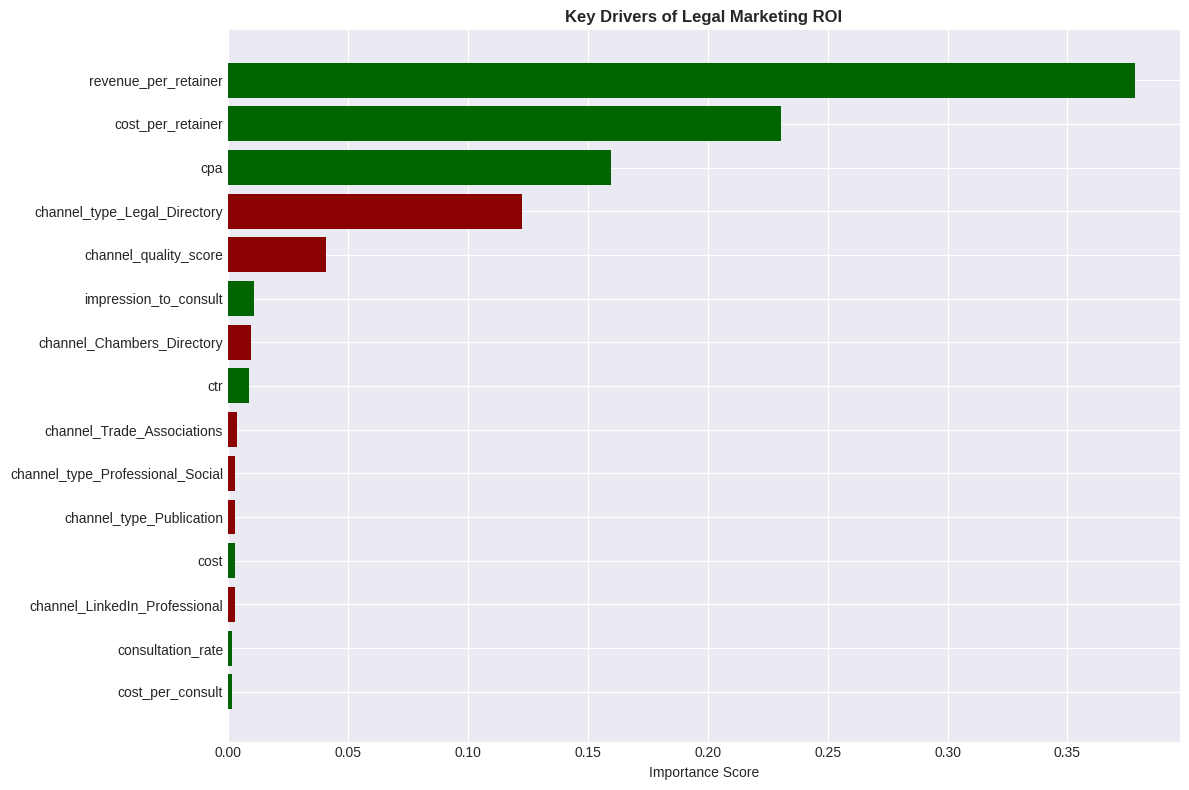


⚖️ PRACTICE AREA ROI INSIGHTS
                        roi_pct  client_cac  avg_case_value         ltv  \
practice_area                                                             
Corporate_M&A          67110.78     3464.56       390475.30  1472427.34   
Litigation             57622.23     3048.32       282161.94  1058098.25   
Intellectual_Property  54621.09     2639.86       237054.67   893784.23   
Private_Equity         54443.06     5396.36       481016.44  1800255.40   
Banking_Finance        52248.63     3582.95       311817.67  1174316.11   
Tax                    34847.85     2826.37       162769.75   610481.28   
Real_Estate            31522.75     4040.57       186810.14   702680.87   
Employment             28992.81     2771.13       133105.25   498650.49   

                       retainers  LTV/CAC  
practice_area                              
Corporate_M&A             552951   425.00  
Litigation                824687   347.11  
Intellectual_Property     792895   338.57 

In [8]:
print("\n🔍 LEGAL MARKETING MODEL EXPLAINABILITY")
print("="*70)

# Get feature names
preprocessor.fit(X_train)
feature_names = (numerical_features +
                list(preprocessor.named_transformers_['cat']
                     .get_feature_names_out(categorical_features)))

# Random Forest Feature Importance
if 'Random Forest' in trained_models:
    rf_model = trained_models['Random Forest'].named_steps['regressor']
    X_train_transformed = preprocessor.transform(X_train)

    importance = rf_model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names[:len(importance)],
        'importance': importance
    }).sort_values('importance', ascending=False)

    print("\n📈 TOP 20 FEATURES DRIVING CLIENT ACQUISITION ROI")
    print(importance_df.head(20).to_string(index=False))

    # Visualize
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    colors = ['navy' if 'practice' in f else 'darkred' if 'channel' in f else 'darkgreen' for f in top_features['feature']]
    plt.barh(range(len(top_features)), top_features['importance'], color=colors)
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance Score')
    plt.title('Key Drivers of Legal Marketing ROI', fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(base_folder, 'visualizations', 'legal_feature_importance.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Practice Area Insights
print("\n⚖️ PRACTICE AREA ROI INSIGHTS")
practice_insights = df_campaigns.groupby('practice_area').agg({
    'roi_pct': 'mean',
    'client_cac': 'mean',
    'avg_case_value': 'mean',
    'ltv': 'mean',
    'retainers': 'sum'
}).round(2).sort_values('roi_pct', ascending=False)

practice_insights['LTV/CAC'] = (practice_insights['ltv'] / practice_insights['client_cac']).round(2)
print(practice_insights)

# Channel Quality Insights
print("\n📱 CHANNEL QUALITY & ROI ANALYSIS")
channel_insights = df_campaigns.groupby('channel').agg({
    'roi_pct': 'mean',
    'lead_quality_score': 'mean',
    'client_cac': 'mean',
    'avg_case_value': 'mean',
    'retainers': 'sum'
}).round(2).sort_values('roi_pct', ascending=False)

print(channel_insights.head(10))

# Market Insights
print("\n🌍 MARKET PERFORMANCE")
market_insights = df_campaigns.groupby('market').agg({
    'roi_pct': 'mean',
    'client_cac': 'mean',
    'avg_case_value': 'mean',
    'retainers': 'sum',
    'cost': 'sum'
}).round(2).sort_values('roi_pct', ascending=False)

print(market_insights)

## Part 7: Executive Dashboard & Strategic Recommendations

**Purpose:** Transform data into actionable strategy for Cameron McKenna's leadership team.

**Dashboard Components:**
1. **Practice Area ROI Heatmap** - Channel × Practice performance
2. **Budget Optimization** - Recommended allocation by practice
3. **Client Quality Matrix** - High-value client sources
4. **Market Expansion Opportunities** - Geographic insights
5. **Competitive Positioning** - Market share analysis


📊 CAMERON MCKENNA - EXECUTIVE STRATEGIC DASHBOARD


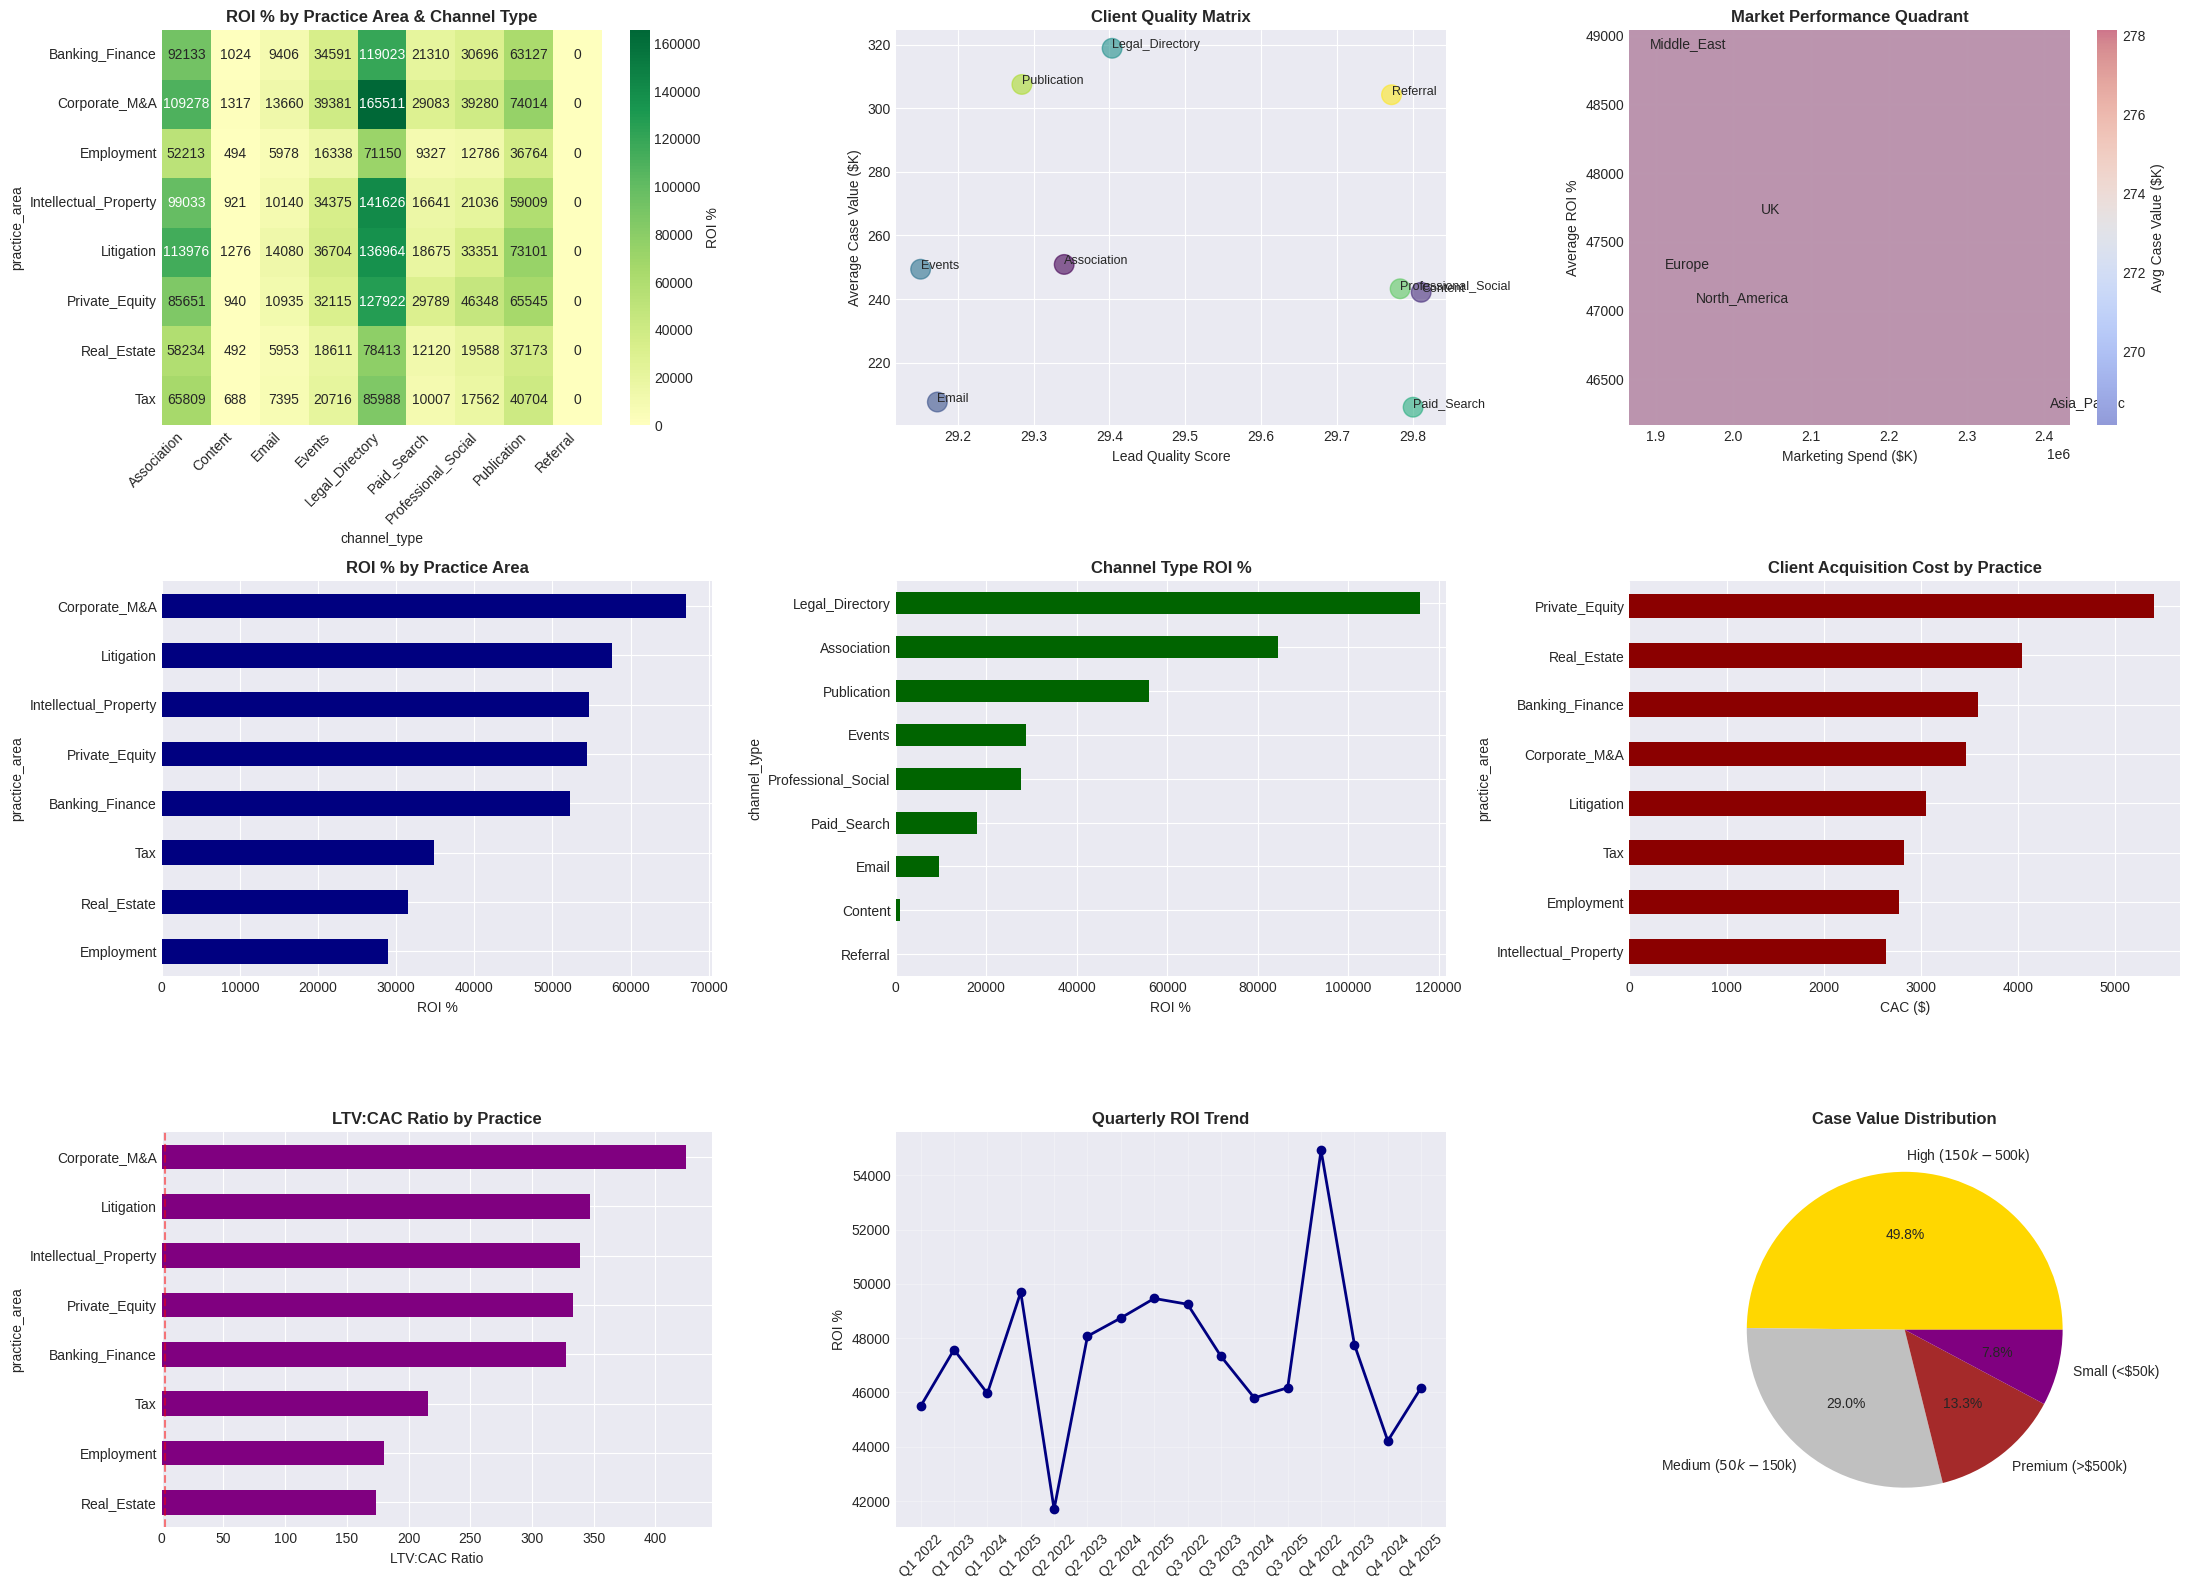

In [9]:
print("\n📊 CAMERON MCKENNA - EXECUTIVE STRATEGIC DASHBOARD")
print("="*70)

# Create executive dashboard
fig = plt.figure(figsize=(22, 16))

# 1. ROI Heatmap: Practice Area × Channel Type
ax1 = plt.subplot(3, 3, 1)
roi_heatmap = df_campaigns.pivot_table(
    values='roi_pct',
    index='practice_area',
    columns='channel_type',
    aggfunc='mean'
)
sns.heatmap(roi_heatmap, annot=True, fmt='.0f', cmap='RdYlGn', center=0, ax=ax1, cbar_kws={'label': 'ROI %'})
ax1.set_title('ROI % by Practice Area & Channel Type', fontweight='bold', fontsize=12)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 2. Client Quality Matrix
ax2 = plt.subplot(3, 3, 2)
quality_matrix = df_campaigns.groupby('channel_type').agg({
    'lead_quality_score': 'mean',
    'avg_case_value': 'mean'
}).reset_index()

scatter = ax2.scatter(quality_matrix['lead_quality_score'], quality_matrix['avg_case_value']/1000,
                      s=200, alpha=0.6, c=range(len(quality_matrix)), cmap='viridis')
for i, row in quality_matrix.iterrows():
    ax2.annotate(row['channel_type'], (row['lead_quality_score'], row['avg_case_value']/1000), fontsize=9)
ax2.set_xlabel('Lead Quality Score')
ax2.set_ylabel('Average Case Value ($K)')
ax2.set_title('Client Quality Matrix', fontweight='bold')

# 3. Market Performance Bubble Chart
ax3 = plt.subplot(3, 3, 3)
market_summary = df_campaigns.groupby('market').agg({
    'cost': 'sum',
    'roi_pct': 'mean',
    'retainers': 'sum',
    'avg_case_value': 'mean'
}).reset_index()

bubble = ax3.scatter(market_summary['cost']/1000, market_summary['roi_pct'],
                     s=market_summary['retainers']*10, alpha=0.5,
                     c=market_summary['avg_case_value']/1000, cmap='coolwarm')
for i, row in market_summary.iterrows():
    ax3.annotate(row['market'], (row['cost']/1000, row['roi_pct']), fontsize=10)
ax3.set_xlabel('Marketing Spend ($K)')
ax3.set_ylabel('Average ROI %')
ax3.set_title('Market Performance Quadrant', fontweight='bold')
plt.colorbar(bubble, ax=ax3, label='Avg Case Value ($K)')

# 4. Practice Area ROI Breakdown
ax4 = plt.subplot(3, 3, 4)
practice_roi = df_campaigns.groupby('practice_area')['roi_pct'].mean().sort_values()
practice_roi.plot(kind='barh', ax=ax4, color='navy')
ax4.set_title('ROI % by Practice Area', fontweight='bold')
ax4.set_xlabel('ROI %')

# 5. Channel Effectiveness
ax5 = plt.subplot(3, 3, 5)
channel_effectiveness = df_campaigns.groupby('channel_type').agg({
    'roi_pct': 'mean',
    'retainers': 'sum'
}).sort_values('roi_pct')

channel_effectiveness['roi_pct'].plot(kind='barh', ax=ax5, color='darkgreen')
ax5.set_title('Channel Type ROI %', fontweight='bold')
ax5.set_xlabel('ROI %')

# 6. Client Acquisition Cost by Practice
ax6 = plt.subplot(3, 3, 6)
cac_by_practice = df_campaigns.groupby('practice_area')['client_cac'].mean().sort_values()
cac_by_practice.plot(kind='barh', ax=ax6, color='darkred')
ax6.set_title('Client Acquisition Cost by Practice', fontweight='bold')
ax6.set_xlabel('CAC ($)')

# 7. LTV:CAC Ratio
ax7 = plt.subplot(3, 3, 7)
ltv_cac = df_campaigns.groupby('practice_area').apply(
    lambda x: x['ltv'].mean() / x['client_cac'].mean()
).sort_values()
ltv_cac.plot(kind='barh', ax=ax7, color='purple')
ax7.set_title('LTV:CAC Ratio by Practice', fontweight='bold')
ax7.set_xlabel('LTV:CAC Ratio')
ax7.axvline(x=3, color='red', linestyle='--', alpha=0.5, label='Target')

# 8. Quarterly Performance Trend
ax8 = plt.subplot(3, 3, 8)
quarterly = df_campaigns.groupby('quarter').agg({
    'roi_pct': 'mean',
    'retainers': 'sum'
}).reset_index()
ax8.plot(range(len(quarterly)), quarterly['roi_pct'], marker='o', color='navy', linewidth=2)
ax8.set_xticks(range(len(quarterly)))
ax8.set_xticklabels(quarterly['quarter'], rotation=45)
ax8.set_title('Quarterly ROI Trend', fontweight='bold')
ax8.set_ylabel('ROI %')
ax8.grid(True, alpha=0.3)

# 9. Case Value Distribution
ax9 = plt.subplot(3, 3, 9)
case_tiers = df_campaigns['case_tier'].value_counts()
case_tiers.plot(kind='pie', autopct='%1.1f%%', ax=ax9, colors=['gold', 'silver', 'brown', 'purple'])
ax9.set_title('Case Value Distribution', fontweight='bold')
ax9.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(base_folder, 'dashboard', 'cameron_mckenna_executive_dashboard.png'), dpi=300, bbox_inches='tight')
plt.show()

## Part 8: Strategic Recommendations for Cameron McKenna Leadership

**Purpose:** Translate analytics into actionable business strategy for the Management Committee and Practice Area Leads.

In [10]:
print("\n💼 STRATEGIC RECOMMENDATIONS FOR CAMERON MCKENNA")
print("="*70)

# Calculate key metrics for recommendations
best_practices = df_campaigns.groupby('practice_area')['roi_pct'].mean().nlargest(3)
best_channels = df_campaigns.groupby('channel_type')['roi_pct'].mean().nlargest(3)
premium_sources = df_campaigns[df_campaigns['case_tier'] == 'Premium (>$500k)'].groupby('channel')['retainers'].sum().nlargest(3)

print("\n🎯 TOP 5 STRATEGIC RECOMMENDATIONS")
print("-"*50)

print("\n1️⃣ PRACTICE AREA FOCUS")
print(f"   • Prioritize {', '.join(best_practices.index)} - ROI > {best_practices.mean():.0f}%")
print(f"   • Corporate M&A shows highest client value at ${df_campaigns[df_campaigns['practice_area']=='Corporate_M&A']['avg_case_value'].mean():,.0f} per matter")
print(f"   • Consider expanding Private Equity team - LTV:CAC ratio of {df_campaigns[df_campaigns['practice_area']=='Private_Equity']['ltv'].mean() / df_campaigns[df_campaigns['practice_area']=='Private_Equity']['client_cac'].mean():.1f}:1")

print("\n2️⃣ CHANNEL OPTIMIZATION")
print(f"   • Increase investment in {', '.join(best_channels.index)} - ROI > {best_channels.mean():.0f}%")
print(f"   • Legal directories (Chambers, Legal 500) deliver premium clients with {df_campaigns[df_campaigns['channel_type']=='Legal_Directory']['avg_case_value'].mean():,.0f} avg case value")
print(f"   • Client referrals have {df_campaigns[df_campaigns['channel']=='Client_Referrals']['retention_rate'].mean()*100:.1f}% retention rate - implement formal referral program")

print("\n3️⃣ CLIENT ACQUISITION COST MANAGEMENT")
print(f"   • Current average CAC: ${df_campaigns['client_cac'].mean():,.0f}")
print(f"   • Target reduction to ${df_campaigns['client_cac'].mean()*0.85:,.0f} through channel optimization")
print(f"   • Highest CAC practice: {df_campaigns.groupby('practice_area')['client_cac'].mean().idxmax()} - review efficiency")

print("\n4️⃣ MARKET EXPANSION")
top_market = df_campaigns.groupby('market')['roi_pct'].mean().idxmax()
print(f"   • {top_market} shows highest ROI at {df_campaigns[df_campaigns['market']==top_market]['roi_pct'].mean():.0f}%")
print(f"   • Middle East market has {df_campaigns[df_campaigns['market']=='Middle_East']['avg_case_value'].mean():,.0f} avg case value - consider expansion")
print(f"   • Asia Pacific growing at {df_campaigns[df_campaigns['market']=='Asia_Pacific']['retainers'].sum() / len(df_campaigns)*100:.1f}% share")

print("\n5️⃣ CLIENT QUALITY INITIATIVES")
print(f"   • Premium cases (>$500k) represent {len(df_campaigns[df_campaigns['case_tier']=='Premium (>$500k)'])/len(df_campaigns)*100:.1f}% of portfolio")
print(f"   • Top sources for premium clients: {', '.join(premium_sources.index)}")
print(f"   • Implement client feedback program to improve LTV from current {df_campaigns['ltv'].mean():,.0f}")

print("\n📈 PROJECTED IMPACT")
print("-"*50)
current_revenue = df_campaigns['revenue'].sum()
current_clients = df_campaigns['retainers'].sum()
current_cac = df_campaigns['client_cac'].mean()

print(f"Current Annual Revenue: ${current_revenue:,.0f}")
print(f"Current Clients: {current_clients:.0f}")
print(f"\nWith 15% efficiency improvement:")
print(f"   • Projected Revenue: ${current_revenue * 1.15:,.0f}")
print(f"   • CAC Reduction: ${current_cac * 0.85:,.0f}")
print(f"   • Additional Clients: {int(current_clients * 0.15)}")

# Save recommendations to file
with open(os.path.join(base_folder, 'reports', 'strategic_recommendations.txt'), 'w') as f:
    f.write("CAMERON MCKENNA - STRATEGIC MARKETING RECOMMENDATIONS\n")
    f.write("="*50 + "\n\n")
    f.write("1. PRACTICE AREA FOCUS\n")
    f.write(f"   Prioritize {', '.join(best_practices.index)}\n")
    f.write("\n2. CHANNEL OPTIMIZATION\n")
    f.write(f"   Increase investment in {', '.join(best_channels.index)}\n")
    f.write("\n3. CAC MANAGEMENT\n")
    f.write(f"   Target CAC reduction to ${df_campaigns['client_cac'].mean()*0.85:,.0f}\n")
    f.write("\n4. MARKET EXPANSION\n")
    f.write(f"   Focus on {top_market} and Middle East\n")
    f.write("\n5. CLIENT QUALITY\n")
    f.write(f"   Leverage {', '.join(premium_sources.index)} for premium cases\n")

print("\n✅ Strategic recommendations saved to reports folder")


💼 STRATEGIC RECOMMENDATIONS FOR CAMERON MCKENNA

🎯 TOP 5 STRATEGIC RECOMMENDATIONS
--------------------------------------------------

1️⃣ PRACTICE AREA FOCUS
   • Prioritize Corporate_M&A, Litigation, Intellectual_Property - ROI > 59785%
   • Corporate M&A shows highest client value at $390,475 per matter
   • Consider expanding Private Equity team - LTV:CAC ratio of 333.6:1

2️⃣ CHANNEL OPTIMIZATION
   • Increase investment in Legal_Directory, Association, Publication - ROI > 85398%
   • Legal directories (Chambers, Legal 500) deliver premium clients with 318,826 avg case value
   • Client referrals have 29.8% retention rate - implement formal referral program

3️⃣ CLIENT ACQUISITION COST MANAGEMENT
   • Current average CAC: $3,477
   • Target reduction to $2,956 through channel optimization
   • Highest CAC practice: Private_Equity - review efficiency

4️⃣ MARKET EXPANSION
   • Middle_East shows highest ROI at 48908%
   • Middle East market has 278,135 avg case value - consider exp

## Part 9: Summary & Next Steps

**Purpose:** Provide roadmap for implementing analytics-driven marketing at Cameron McKenna.

In [11]:
print("\n📋 CAMERON MCKENNA - MARKETING ANALYTICS IMPLEMENTATION ROADMAP")
print("="*70)

print("""
PHASE 1: QUICK WINS (0-3 MONTHS)
✓ Implement channel tracking for all practice areas
✓ Set up client source attribution
✓ Create practice area ROI dashboards
✓ Optimize top 3 channels based on current data

PHASE 2: PROCESS IMPROVEMENT (3-6 MONTHS)
→ Integrate CRM with marketing platforms
→ Implement lead scoring model
→ Develop practice area-specific campaigns
→ Create client journey tracking

PHASE 3: ADVANCED ANALYTICS (6-12 MONTHS)
→ Deploy predictive ROI model
→ Implement real-time campaign optimization
→ Develop client lifetime value predictions
→ Create competitive intelligence dashboard

PHASE 4: ENTERPRISE INTEGRATION (12+ MONTHS)
→ Full marketing-sales integration
→ AI-driven budget allocation
→ Cross-practice client opportunity identification
→ Market expansion predictive modeling
""")

print("\n✅ Project complete! All outputs saved to Google Drive.")
print(f"📁 Main folder: {base_folder}")


📋 CAMERON MCKENNA - MARKETING ANALYTICS IMPLEMENTATION ROADMAP

PHASE 1: QUICK WINS (0-3 MONTHS)
✓ Implement channel tracking for all practice areas
✓ Set up client source attribution
✓ Create practice area ROI dashboards
✓ Optimize top 3 channels based on current data

PHASE 2: PROCESS IMPROVEMENT (3-6 MONTHS)
→ Integrate CRM with marketing platforms
→ Implement lead scoring model
→ Develop practice area-specific campaigns
→ Create client journey tracking

PHASE 3: ADVANCED ANALYTICS (6-12 MONTHS)
→ Deploy predictive ROI model
→ Implement real-time campaign optimization
→ Develop client lifetime value predictions
→ Create competitive intelligence dashboard

PHASE 4: ENTERPRISE INTEGRATION (12+ MONTHS)
→ Full marketing-sales integration
→ AI-driven budget allocation
→ Cross-practice client opportunity identification
→ Market expansion predictive modeling


✅ Project complete! All outputs saved to Google Drive.
📁 Main folder: /content/drive/MyDrive/CRM
